In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)


path_file = "../data/ab_data.csv"
df = pd.read_csv(path_file)
df['timestamp'] = pd.to_datetime(df['timestamp'])


In [2]:
print(f"Sətir sayı: {df.shape[0]:,}")
print(f"Sütunlar: {df.columns.tolist()}")
print()
print("Qrup ölçüləri:")
print(df['group'].value_counts())
print()
print("Landing page paylanması:")
print(df['landing_page'].value_counts())
print()
print(f"Tarix aralığı: {df['timestamp'].min()} -> {df['timestamp'].max()}")

df.head()

Sətir sayı: 294,478
Sütunlar: ['user_id', 'timestamp', 'group', 'landing_page', 'converted']

Qrup ölçüləri:
group
treatment    147276
control      147202
Name: count, dtype: int64

Landing page paylanması:
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

Tarix aralığı: 2017-01-02 13:42:05.378582 -> 2017-01-24 13:41:54.460509


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
misassigned_mask = (
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page'))
)
n_misassigned = misassigned_mask.sum()
print(f"Səhv təyin edilmiş sətir sayı: {n_misassigned:,}")
print(f"treatment qrupunda old_page görənlər: {((df['group']=='treatment') & (df['landing_page']=='old_page')).sum():,}")
print(f"control qrupunda new_page görənlər: {((df['group']=='control') & (df['landing_page']=='new_page')).sum():,}")
df_clean = df[~misassigned_mask].copy()
print(f"\nTəmizləmədən sonra: {len(df_clean):,} sətir (əvvəlki {len(df):,}-dən)")


Səhv təyin edilmiş sətir sayı: 3,893
treatment qrupunda old_page görənlər: 1,965
control qrupunda new_page görənlər: 1,928

Təmizləmədən sonra: 290,585 sətir (əvvəlki 294,478-dən)


In [4]:
dupe_count = df_clean['user_id'].duplicated().sum()
print(f"Təkrarlanan user_id sayı: {dupe_count}")
if dupe_count > 0:
    df_clean = df_clean.drop_duplicates(subset='user_id', keep='first')
    print(f"Təkrarlar silindikdən sonra: {len(df_clean):,} sətir")


Təkrarlanan user_id sayı: 1
Təkrarlar silindikdən sonra: 290,584 sətir


In [5]:
group_summary = df_clean.groupby('group').agg(
    User_Count=('user_id', 'count'),
    Conversions=('converted', 'sum')
)
group_summary['Conversion_Rate_%'] = (group_summary['Conversions'] / group_summary['User_Count'] * 100).round(4)
group_summary


,User_Count,Conversions,Conversion_Rate_%
group,,,
control,145274,17489,12.0386
treatment,145310,17264,11.8808


In [6]:
control_rate = group_summary.loc['control', 'Conversion_Rate_%']
treatment_rate = group_summary.loc['treatment', 'Conversion_Rate_%']
abs_diff = treatment_rate - control_rate
rel_diff = abs_diff / control_rate * 100
print(f"Control conversion rate:   {control_rate:.4f}%")
print(f"Treatment conversion rate: {treatment_rate:.4f}%")
print(f"Mütləq fərq ( treatment - control ): {abs_diff:+.4f} pp")
print(f"Nisbi fərq: {rel_diff:+.4f}%")


Control conversion rate:   12.0386%
Treatment conversion rate: 11.8808%
Mütləq fərq ( treatment - control ): -0.1578 pp
Nisbi fərq: -1.3108%


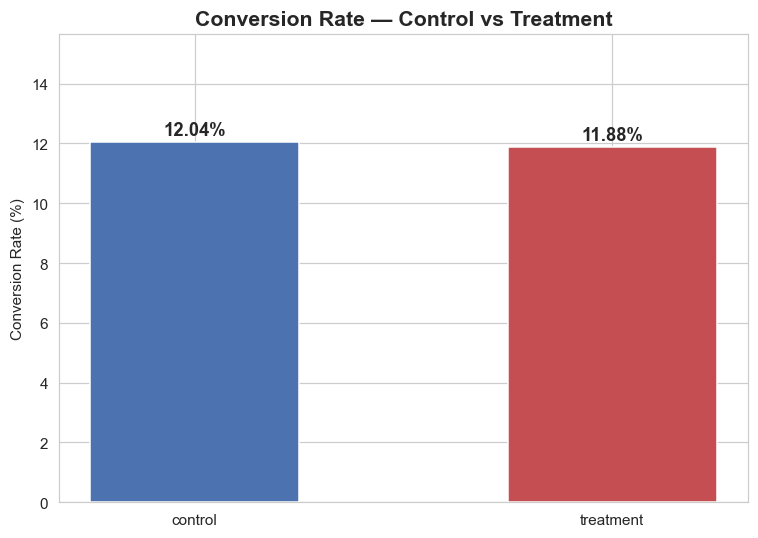

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#4C72B0', '#C44E52']
bars = ax.bar(group_summary.index, group_summary['Conversion_Rate_%'], color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, group_summary['Conversion_Rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Conversion Rate — Control vs Treatment', fontsize=14, fontweight='bold')
ax.set_ylabel('Conversion Rate ( % )')
ax.set_ylim(0, max(group_summary['Conversion_Rate_%']) * 1.3)
plt.tight_layout()
plt.savefig('conversion_rate_bar.png', dpi=150, bbox_inches='tight')
plt.show()


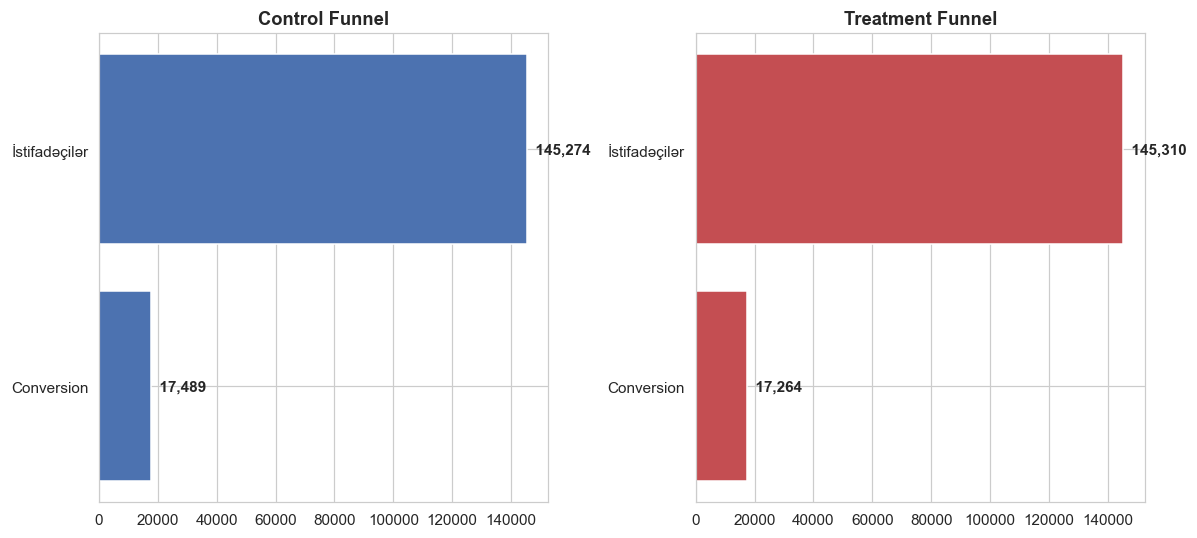

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, grp, color in zip(axes, ['control', 'treatment'], ['#4C72B0', '#C44E52']):
    users = group_summary.loc[grp, 'User_Count']
    conversions = group_summary.loc[grp, 'Conversions']
    stages = ['İstifadəçilər', 'Conversion']
    values = [users, conversions]
    ax.barh(stages, values, color=color, edgecolor='white')
    for i, v in enumerate(values):
        ax.text(v, i, f'  {v:,}', va='center', fontweight='bold')
    ax.set_title(f'{grp.capitalize()} Funnel', fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('conversion_funnel.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
df_clean['date'] = df_clean['timestamp'].dt.date
daily_conversion = df_clean.groupby(['date', 'group'])['converted'].mean().unstack() * 100
daily_conversion.round(2)


group,control,treatment
date,,
2017-01-02,12.56,11.99
2017-01-03,11.38,11.38
2017-01-04,12.19,11.66
2017-01-05,12.32,11.50
2017-01-06,11.53,12.35
2017-01-07,12.10,11.62
2017-01-08,11.89,12.07
2017-01-09,11.96,11.81
2017-01-10,11.29,12.63


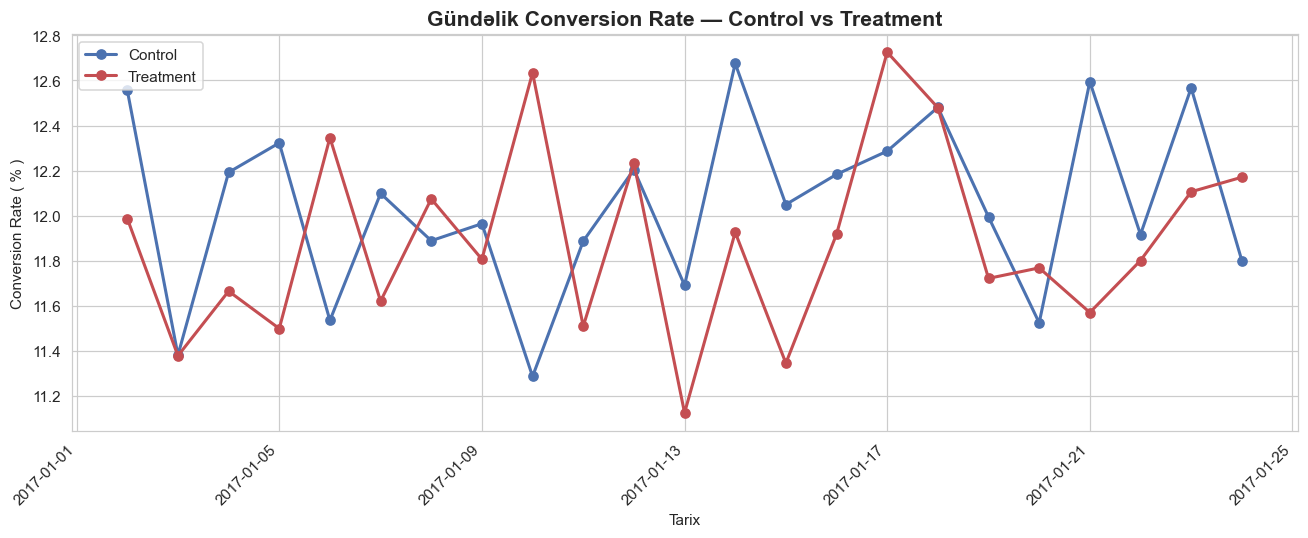

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_conversion.index, daily_conversion['control'], marker='o',
        label='Control', color='#4C72B0', linewidth=2)
ax.plot(daily_conversion.index, daily_conversion['treatment'], marker='o',
        label='Treatment', color='#C44E52', linewidth=2)
ax.set_title('Gündəlik Conversion Rate — Control vs Treatment', fontsize=14, fontweight='bold')
ax.set_xlabel('Tarix')
ax.set_ylabel('Conversion Rate ( % )')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('daily_conversion_rate.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
df_clean['hour'] = df_clean['timestamp'].dt.hour
hourly_conversion = df_clean.groupby(['hour', 'group'])['converted'].mean().unstack() * 100
hourly_conversion.round(2)


group,control,treatment
hour,,
0,12.04,12.03
1,11.61,11.13
2,11.33,11.34
3,11.49,11.51
4,12.08,10.74
5,12.36,11.82
6,12.77,11.49
7,11.93,11.59
8,11.70,11.99


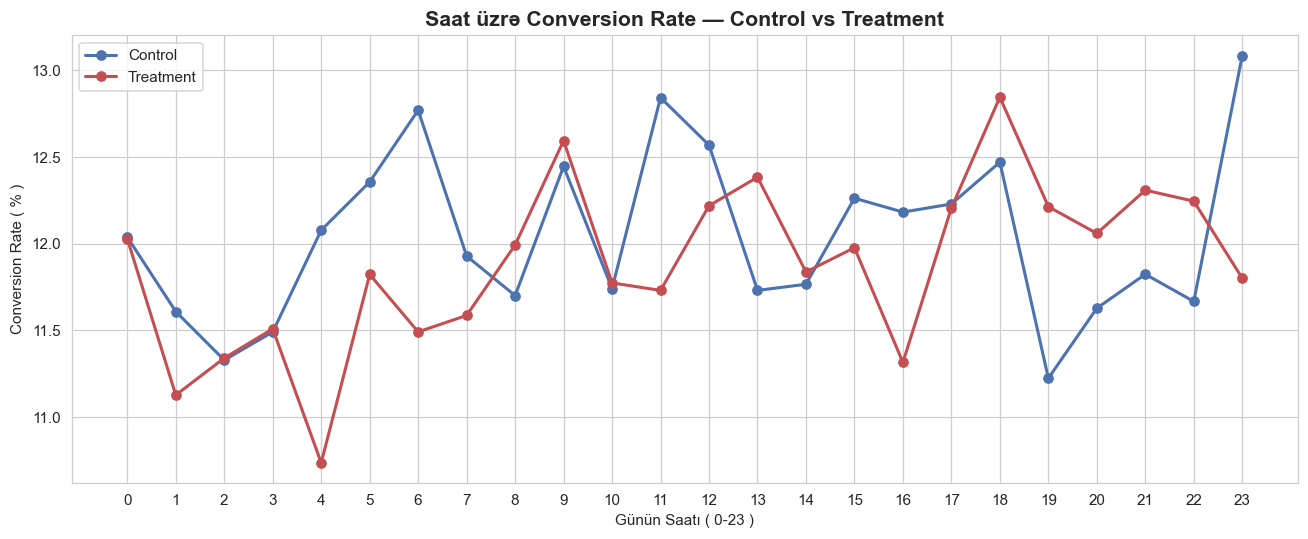

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_conversion.index, hourly_conversion['control'], marker='o',
        label='Control', color='#4C72B0', linewidth=2)
ax.plot(hourly_conversion.index, hourly_conversion['treatment'], marker='o',
        label='Treatment', color='#C44E52', linewidth=2)
ax.set_title('Saat üzrə Conversion Rate — Control vs Treatment', fontsize=14, fontweight='bold')
ax.set_xlabel('Günün Saatı ( 0-23 )')
ax.set_ylabel('Conversion Rate ( % )')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('hourly_conversion_rate.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
extra_conversions_per_1m = (abs_diff / 100) * 1_000_000
print(f"Mütləq fərq: {abs_diff:+.4f} pp")
print(f"1 milyon istifadəçiyə tətbiq edilsə: {extra_conversions_per_1m:+.0f} conversion")
if extra_conversions_per_1m < 0:
    print(f"\n=> Yeni səhifəyə keçid hər 1M istifadəçidə TƏXMİNƏN {abs(extra_conversions_per_1m):.0f} conversion İTKİSİNƏ səbəb olar.")
else:
    print(f"\n=> Yeni səhifəyə keçid hər 1M istifadəçidə TƏXMİNƏN {extra_conversions_per_1m:.0f} əlavə conversion gətirər.")


Mütləq fərq: -0.1578 pp
1 milyon istifadəçiyə tətbiq edilsə: -1578 conversion

=> Yeni səhifəyə keçid hər 1M istifadəçidə TƏXMİNƏN 1578 conversion İTKİSİNƏ səbəb olar.
